# Exploratory Data Analysis (EDA)

## Objective

The objective of this stage is to explore the dataset visually and statistically in order to identify patterns, relatioships and insights that may help explain customer churn.

The findings from this analysis will guide the data preprocessing and feature engineering steps.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
file_name = '../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(file_name)

## Churn Distribution

In this section we analyze the distribution of target variable.

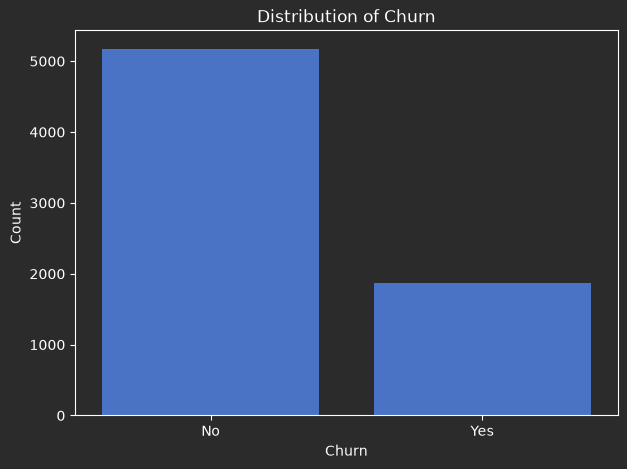

In [5]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.title('Distribution of Churn')
plt.show()

## Numerical Feature Analysis

In this section, the numerical features are explored using histograms and box plots to understand their distributions and identify potential outliers.

`TotalCharges` feature converts to float for EDA

In [6]:
df[df['TotalCharges'].str.strip() == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [7]:
df['TotalCharges'] = df['TotalCharges'].replace("", np.nan)
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)

In [8]:
df['TotalCharges'] = pd.to_numeric((df['TotalCharges']))

In [9]:
df['TotalCharges'].dtype

dtype('float64')

### Tenure Distribution

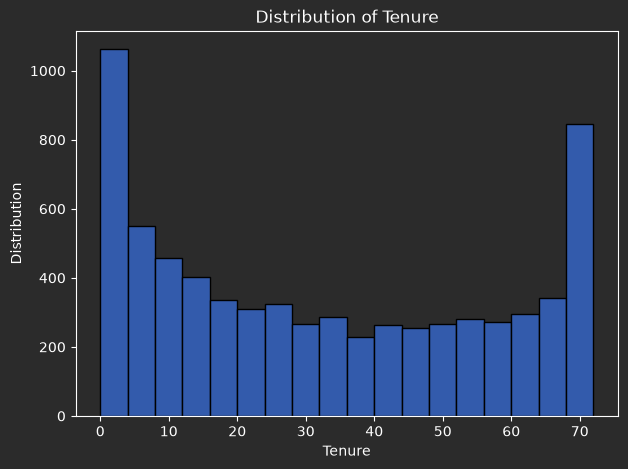

In [10]:
plt.figure(figsize=(7, 5))
sns.histplot(data=df, x='tenure', bins=18)
plt.xlabel('Tenure')
plt.ylabel('Distribution')
plt.title('Distribution of Tenure')
plt.show()

### Observation

The distribution of `tenure` shows that a large number of customers have relatively short service periods.

Although the number of customers decreases in the middle tenure range, there is still a considerable number of long-term customers.

### Monthly Charges Distribution

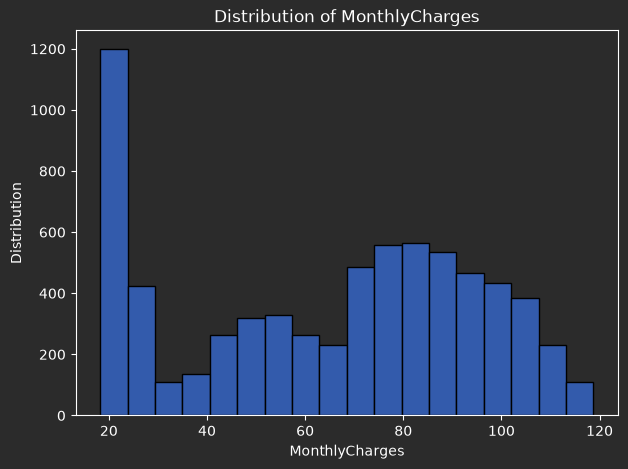

In [11]:
plt.figure(figsize=(7, 5))
sns.histplot(data=df, x='MonthlyCharges')
plt.xlabel('MonthlyCharges')
plt.ylabel('Distribution')
plt.title('Distribution of MonthlyCharges')
plt.show()

### Observation

The distribution of `MonthlyCharges` shows that customers has relatively low monthly charges, while another group is concentrated around higher monthly charges.

### Total Charges Distribution

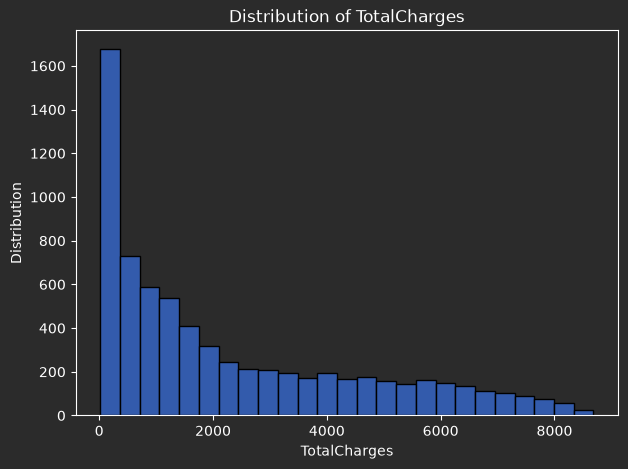

In [12]:
plt.figure(figsize=(7, 5))
sns.histplot(data=df, x='TotalCharges')
plt.xlabel('TotalCharges')
plt.ylabel('Distribution')
plt.title('Distribution of TotalCharges')
plt.show()

### Observation

The distribution of `TotalCharges` is right-skewed.

A large number of customers have relatively low total charges, and the number of customers decreases as total charges increase.

### Numerical Features Outlier Analysis

In this section box plots are used to visualize the spread of numerical features and identify potentiall outliers.


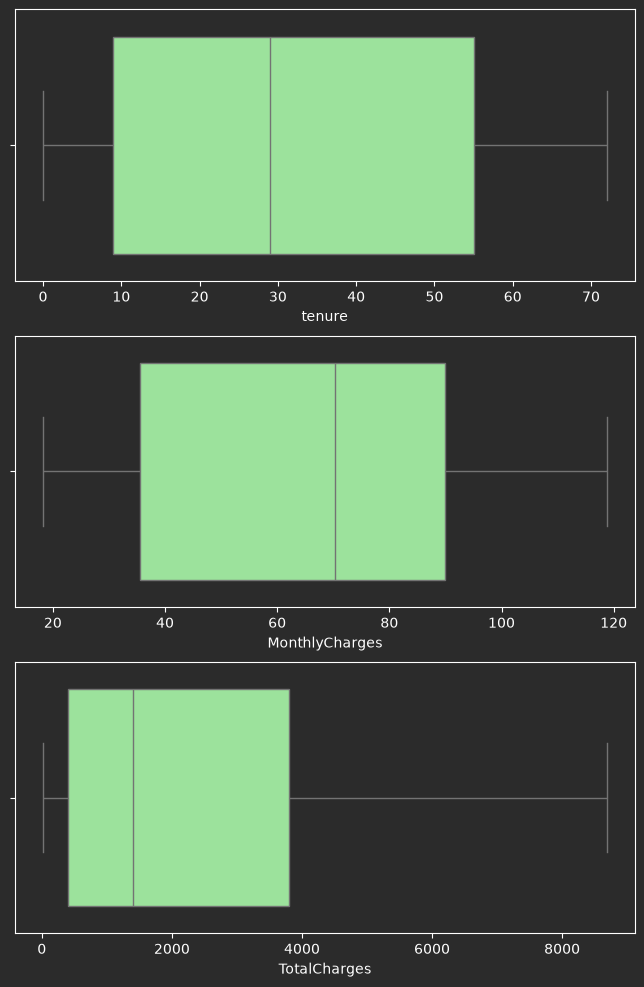

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(8, 12))
sns.boxplot(data=df, x='tenure', ax=axes[0], color='lightgreen')
sns.boxplot(data=df, x='MonthlyCharges', ax=axes[1], color='lightgreen')
sns.boxplot(data=df, x='TotalCharges', ax=axes[2], color='lightgreen')
plt.show()

### Observation

Box plots of numerical features were analyzed to identify potential outliers.

No significant outliers were detected in the numerical features.

No outlier removal is required at this stage.

## Categorical Feature Analysis

Understanding the distribution of categorical variables helps identify dominant categories, detect potential data imbalance and gain insights into customer characteristics before analyzing their relationship with churn.

### Gender Distribution

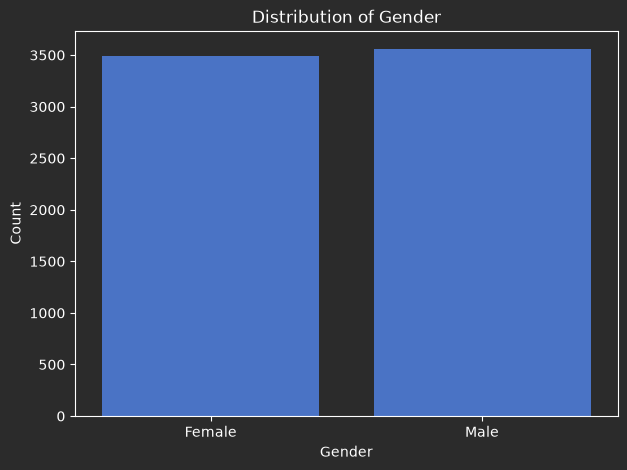

In [14]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Distribution of Gender')
plt.show()

### Senior Citizen Distribution

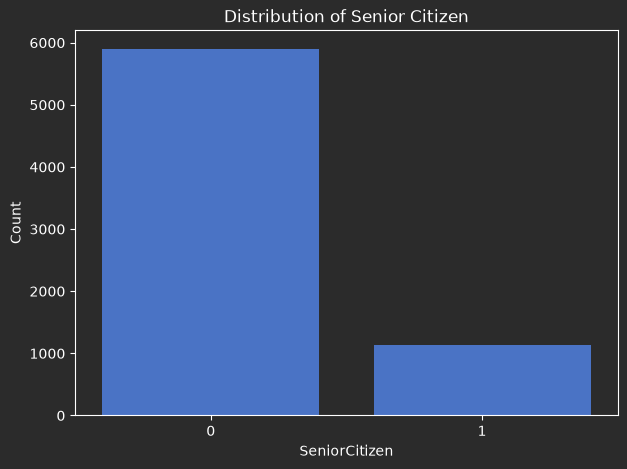

In [15]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='SeniorCitizen')
plt.xlabel('SeniorCitizen')
plt.ylabel('Count')
plt.title('Distribution of Senior Citizen')
plt.show()

### Partner Distribution

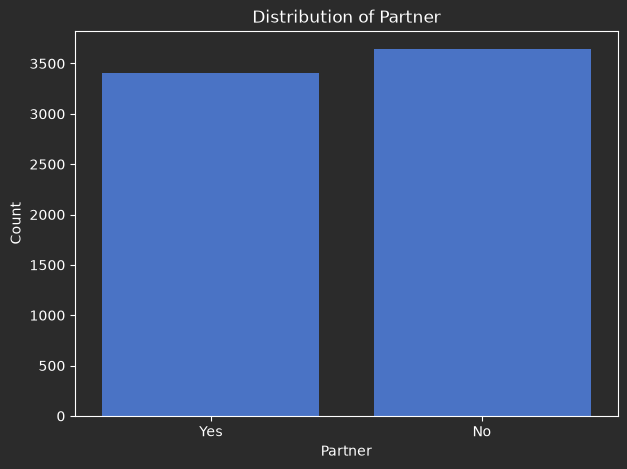

In [16]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Partner')
plt.xlabel('Partner')
plt.ylabel('Count')
plt.title('Distribution of Partner')
plt.show()

### Dependents Distribution

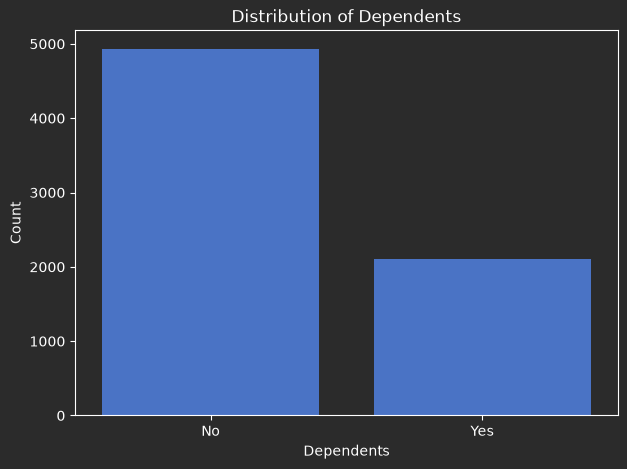

In [17]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Dependents')
plt.xlabel('Dependents')
plt.ylabel('Count')
plt.title('Distribution of Dependents')
plt.show()

### Phone Service Distribution

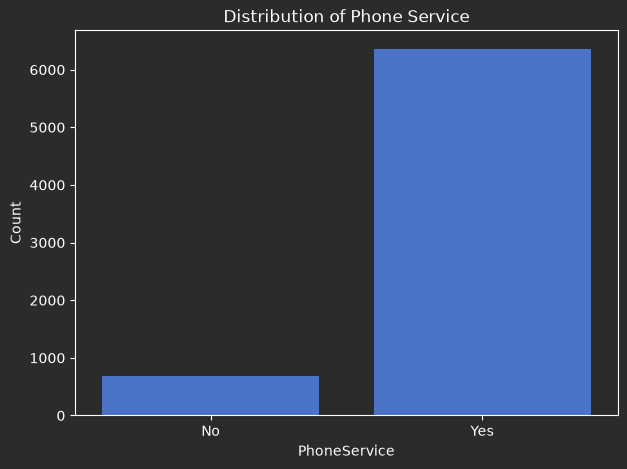

In [18]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='PhoneService')
plt.xlabel('PhoneService')
plt.ylabel('Count')
plt.title('Distribution of Phone Service')
plt.show()

### Observation

The majority of customers have phone service. This indicates that phone service is a common service among customers in the dataset.

### Multiple Lines Distribution

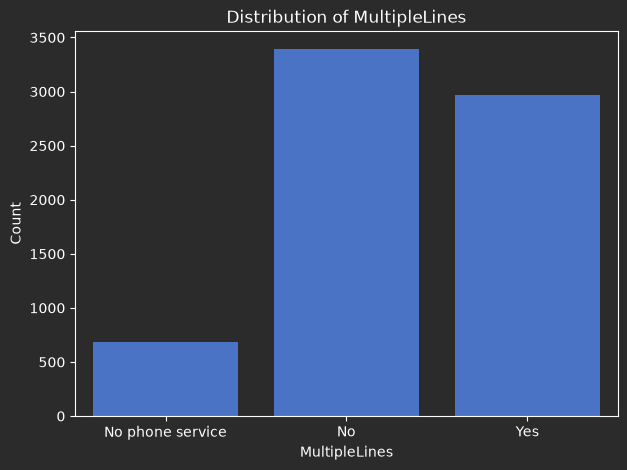

In [19]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='MultipleLines')
plt.xlabel('MultipleLines')
plt.ylabel('Count')
plt.title('Distribution of MultipleLines')
plt.show()

### Internet Service Distribution

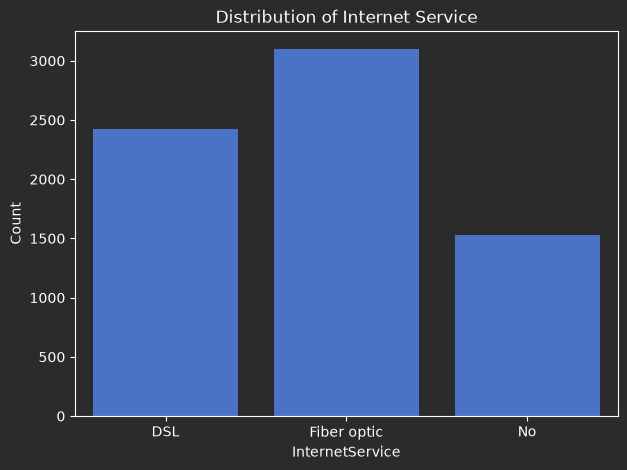

In [20]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='InternetService')
plt.xlabel('InternetService')
plt.ylabel('Count')
plt.title('Distribution of Internet Service')
plt.show()

### Observation

The distribution of the Internet Service feature shows that Fiber optic is the most common internet service type among customers followed by DSL.
Customers wihtout internet service represent the smallest group in the dataset.

### Online Security Distribution

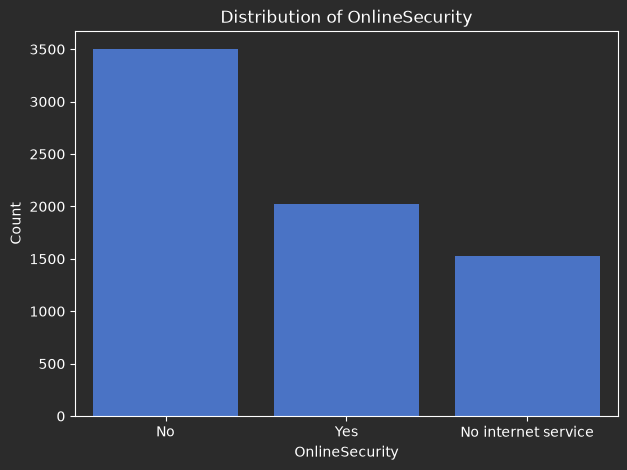

In [21]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='OnlineSecurity')
plt.xlabel('OnlineSecurity')
plt.ylabel('Count')
plt.title('Distribution of OnlineSecurity')
plt.show()

### Online Backup Distribution

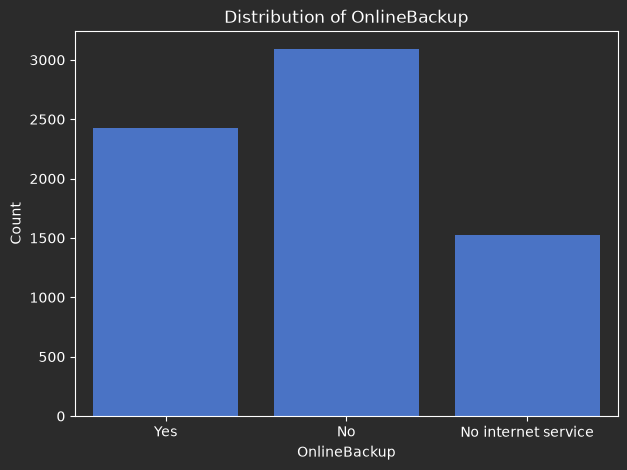

In [22]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='OnlineBackup')
plt.xlabel('OnlineBackup')
plt.ylabel('Count')
plt.title('Distribution of OnlineBackup')
plt.show()

### Device Protection Distribution

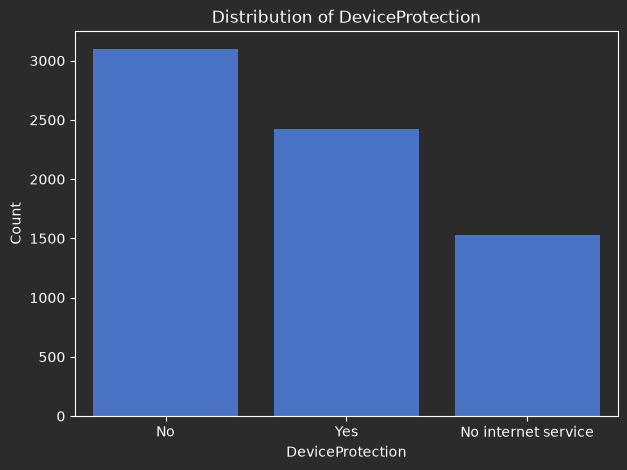

In [23]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='DeviceProtection')
plt.xlabel('DeviceProtection')
plt.ylabel('Count')
plt.title('Distribution of DeviceProtection')
plt.show()

### Tech Support Distribution

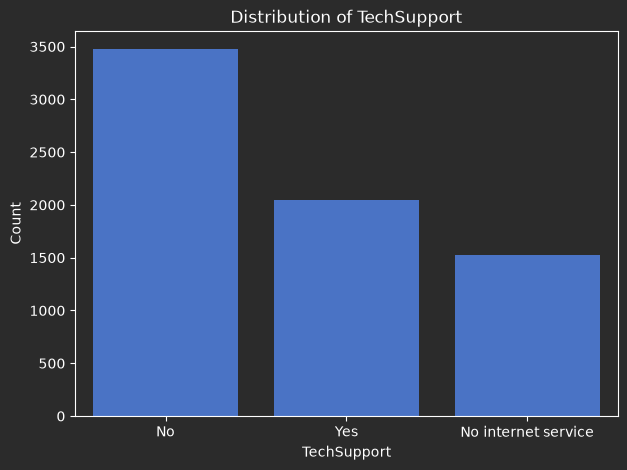

In [24]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='TechSupport')
plt.xlabel('TechSupport')
plt.ylabel('Count')
plt.title('Distribution of TechSupport')
plt.show()

### Streaming TV Distribution

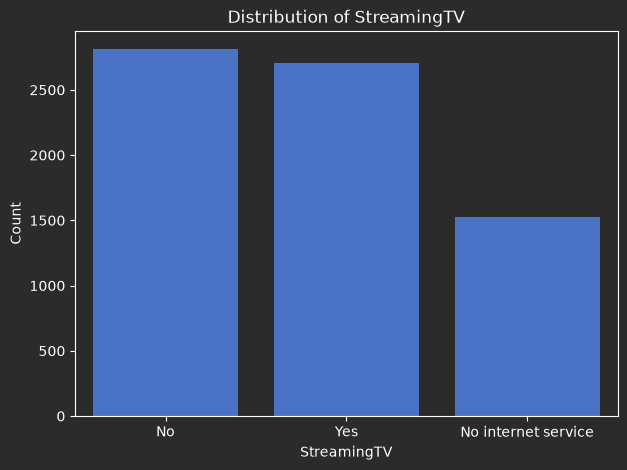

In [25]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='StreamingTV')
plt.xlabel('StreamingTV')
plt.ylabel('Count')
plt.title('Distribution of StreamingTV')
plt.show()

### Streaming Movies Distribution

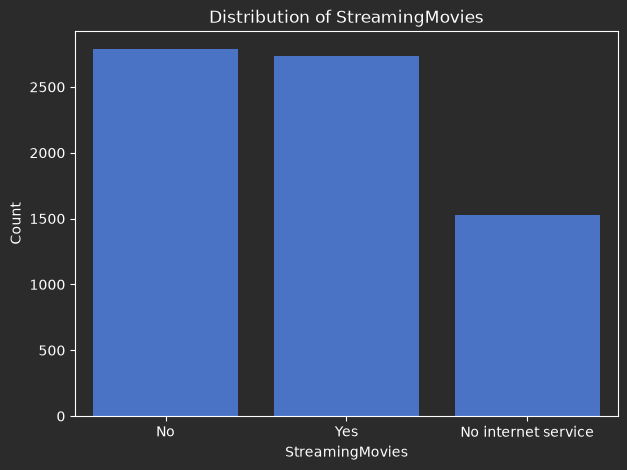

In [26]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='StreamingMovies')
plt.xlabel('StreamingMovies')
plt.ylabel('Count')
plt.title('Distribution of StreamingMovies')
plt.show()

### Contract Distribution

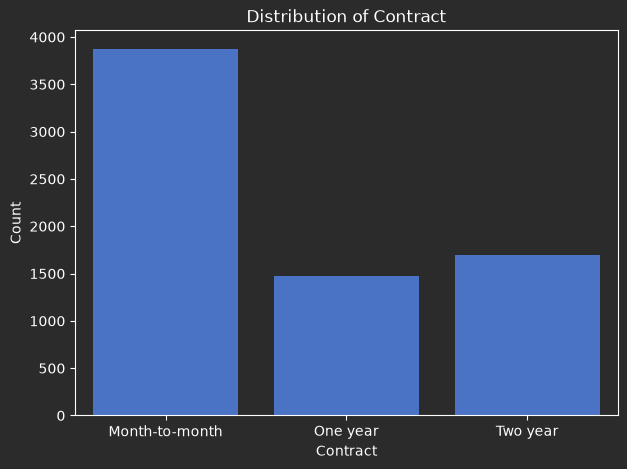

In [27]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Contract')
plt.xlabel('Contract')
plt.ylabel('Count')
plt.title('Distribution of Contract')
plt.show()

### Observation

The distribution of the Contract feature shows that monthly contracts are the most common type among customers. Two-year contracts are more common than one-year contracts, while both long-term contract types have considerably fewer customers compared to monthly contracts.

### Paperless Billing Distribution

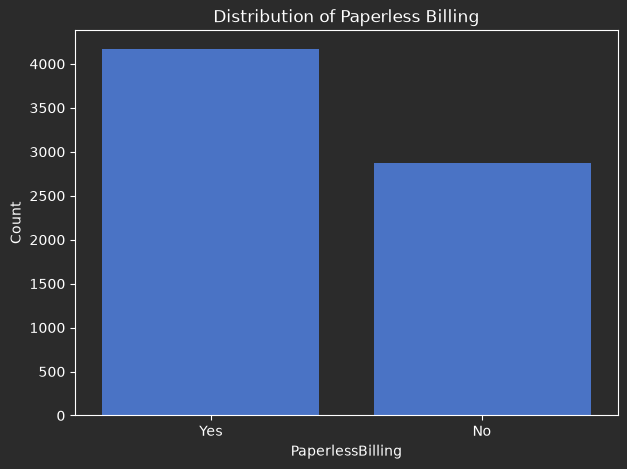

In [28]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='PaperlessBilling')
plt.xlabel('PaperlessBilling')
plt.ylabel('Count')
plt.title('Distribution of Paperless Billing')
plt.show()

### Payment Method Distribution

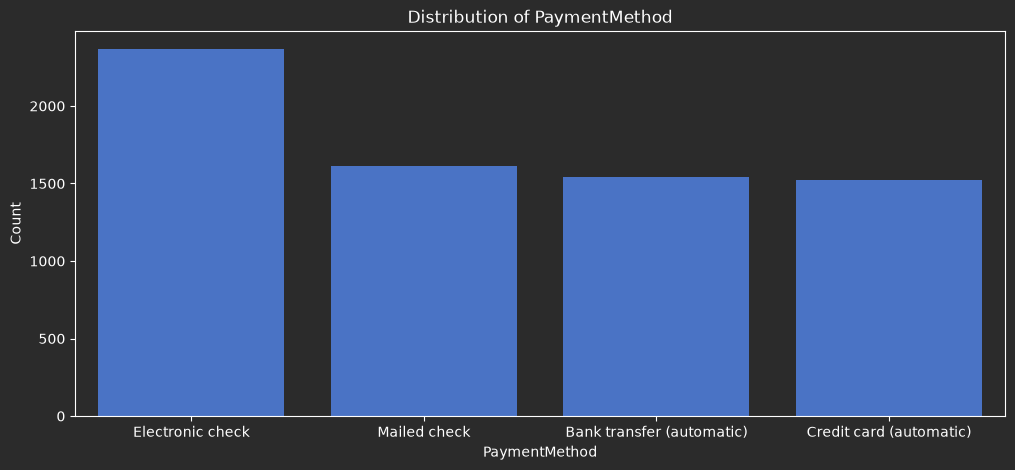

In [29]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='PaymentMethod')
plt.xlabel('PaymentMethod')
plt.ylabel('Count')
plt.title('Distribution of PaymentMethod')
plt.show()

## Feature Relationship with Churn

In this section we explore the relationship between customer features and the target variable `Churn`.
The objective is to identify patterns that may help explain customer churn and provide useful insights for predictive modeling.

### Contract vs Churn

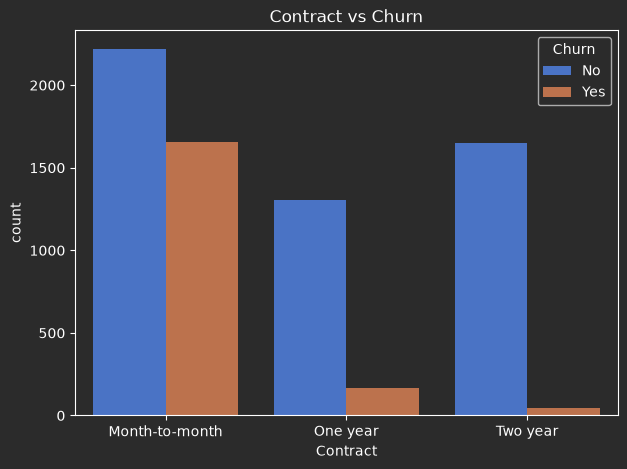

In [31]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Contract vs Churn')
plt.show()

### Insight

Customers with long-term contracts (one-year and two-year) exhibit substantially lower churn compared to customers with month-to-month contracts.
This suggests that contract duration may be an important factor associated with customer retention.

### Internet Service vs Churn

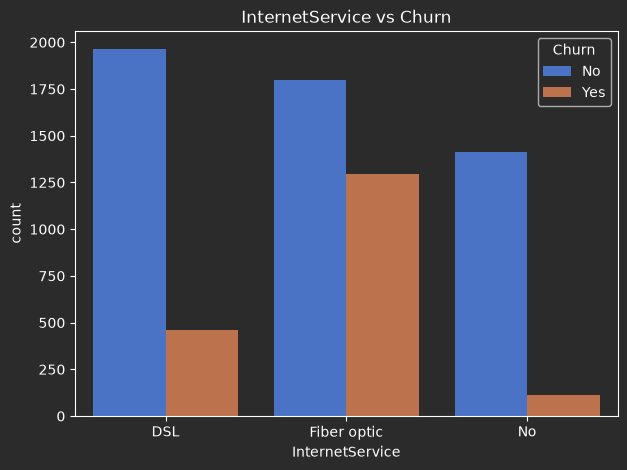

In [32]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('InternetService vs Churn')
plt.show()

### Insight

Among customers who churned, the majority were using Fiber Optic internet service.

### Online Security vs Churn

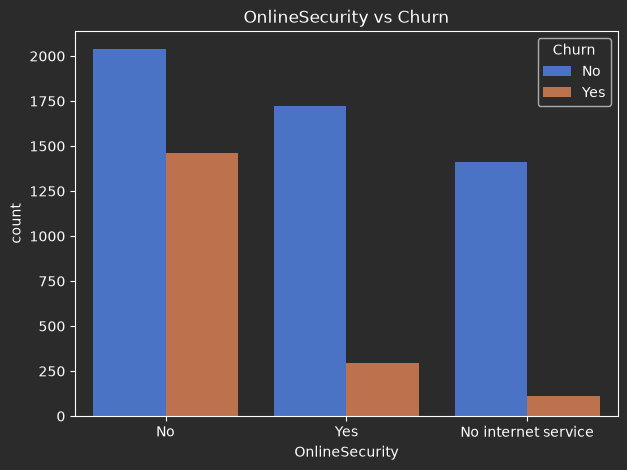

In [33]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='OnlineSecurity', hue='Churn')
plt.title('OnlineSecurity vs Churn')
plt.show()

### Insight

Among customers who churned, the majority did not have online security service.

### Tech Support vs Churn

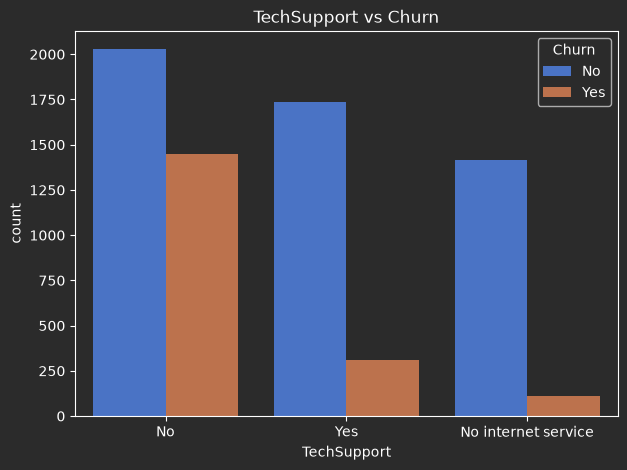

In [34]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='TechSupport', hue='Churn')
plt.title('TechSupport vs Churn')
plt.show()

### Insight

Among customers who churned, the majority did not have Tech Support service.

### Payment Method vs Churn

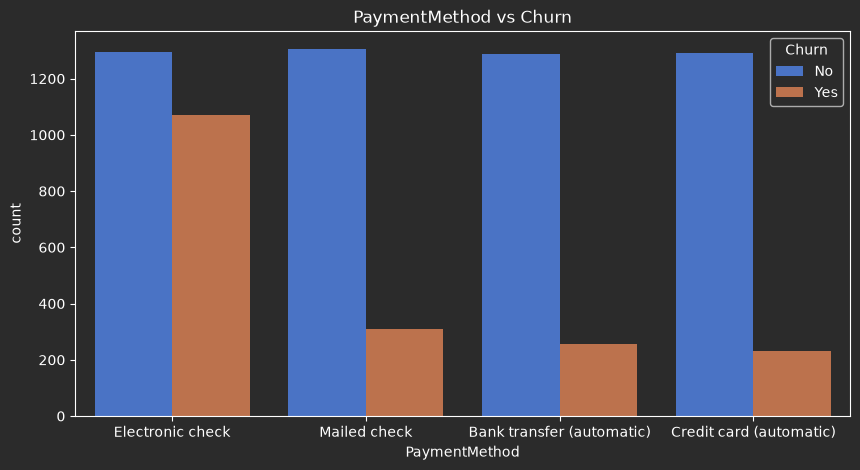

In [38]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='PaymentMethod', hue='Churn')
plt.title('PaymentMethod vs Churn')
plt.show()

### Insight
Among customers who churned, electronic check was the most common payment method.

### Tenure vs Churn

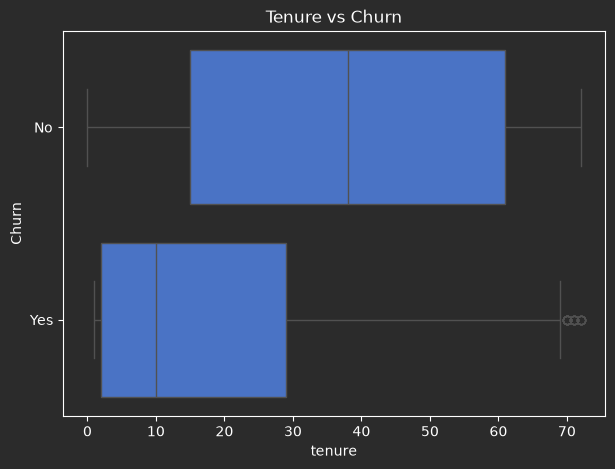

In [39]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='tenure', y='Churn')
plt.title('Tenure vs Churn')
plt.show()

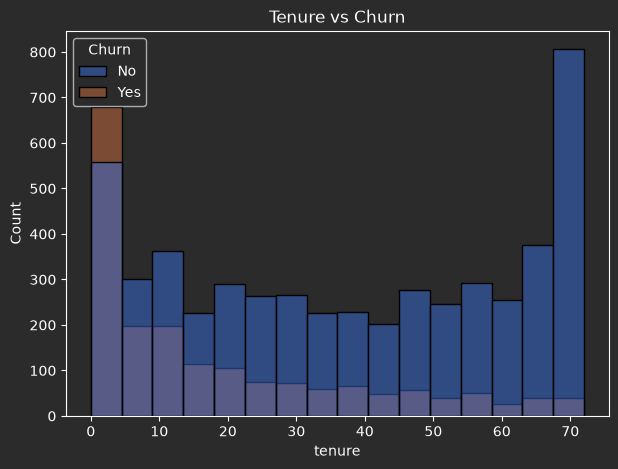

In [40]:
plt.figure(figsize=(7, 5))
sns.histplot(data=df, x='tenure', hue='Churn')
plt.title('Tenure vs Churn')
plt.show()

### Insight

Customers who churned generally have shorter tenure compared to customers who stayed. This suggests that customers with shorter tenure may have a higher risk of churn.

### Monthly Charges vs Churn

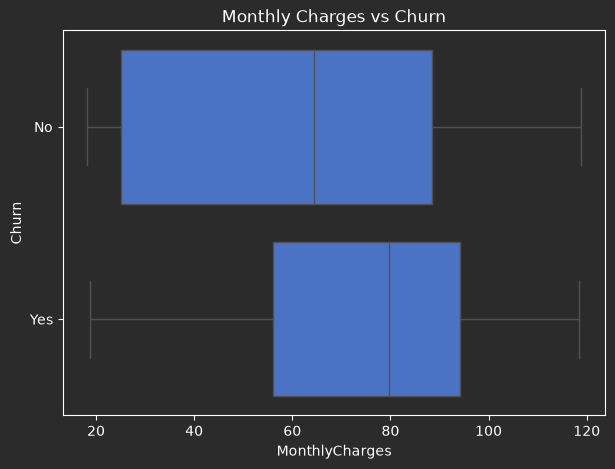

In [41]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='MonthlyCharges', y='Churn')
plt.title('Monthly Charges vs Churn')
plt.show()

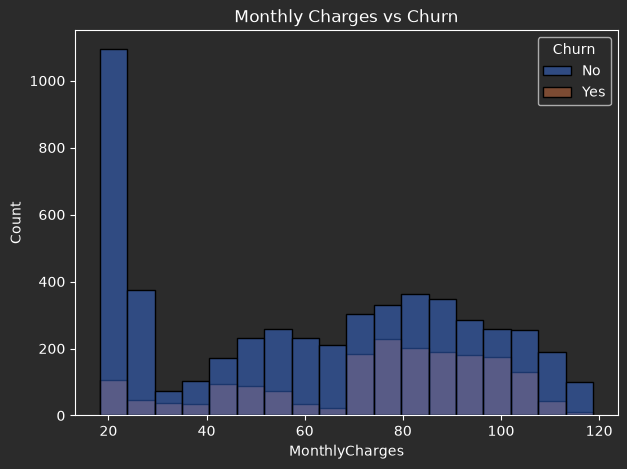

In [43]:
plt.figure(figsize=(7, 5))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn')
plt.title('Monthly Charges vs Churn')
plt.show()

### Insight

Customers with lower monthly charges appear to have lower churn rates.
However, among customers  with higher monthly charges both churned and retained customers are present, sugguesting  that monthly charges alone may not be a strong predictor of churn.

### Total Charges vs Churn

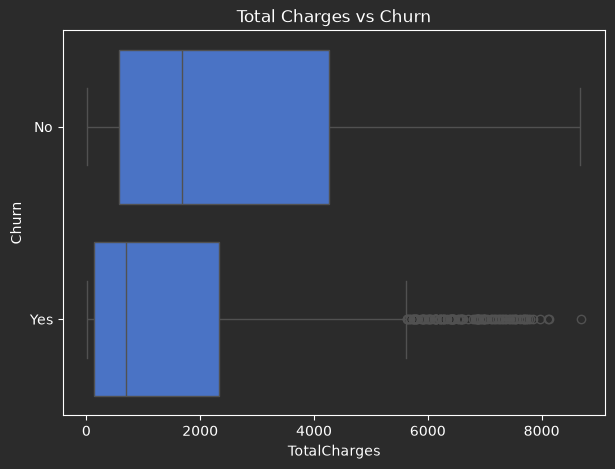

In [44]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='TotalCharges', y='Churn')
plt.title('Total Charges vs Churn')
plt.show()

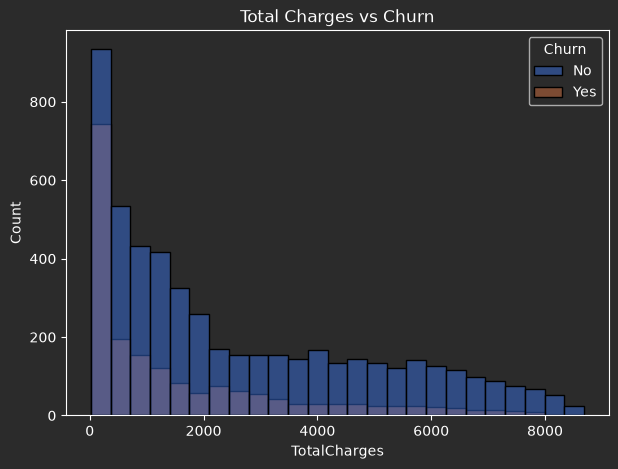

In [45]:
plt.figure(figsize=(7, 5))
sns.histplot(data=df, x='TotalCharges', hue='Churn')
plt.title('Total Charges vs Churn')
plt.show()

### Insight

Customers who churned generally have lower total charges compared to retained customers.
However, some churned customers have high total charges, which may represent long-term customers who left despite having a higher accumulated spending.

## EDA Summary

Based on the exploratory data analysis, several important patterns were identified:

- The target variable `Churn` is imbalanced with fewer churned customers compared to retained customers.
- Customers with shorter tenure appear to have a higher tendency to churn, while long-term customers are more likely to stay.
- Contract type shows a strong relationship with churn. Customers with monthly contracts have higher churn compared to customers with long-term contracts.
- Customers who churned are more frequently associated with the absence of additional services such as OnlineSecurity and TechSupport.
- Fiber optic internet service appears frequently among churned customers and requires further investigations.
- Electronic check is the most common payment method among churned customers.
- Customers who churned generally have lower total charges, although some hugh-value customers also churned.

